# tACS Bandit Task Analyses

Analysis notebook for: *Examining the effects of theta-tACS over left DLPFC on reward-based learning across the adult lifespan*

This notebook implements all pre-registered analyses (H1.1, H1.2, H2.1, H2.2; https://osf.io/vhyz2) plus secondary and exploratory analyses. It reads trial-level behavioral data from the `tacs_bandit` repository, computes WSLS and Rescorla-Wagner parameters, and merges with REDCap-derived cognitive and demographic data.

## 0. Setup and Configuration

In [17]:
import os
import glob
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats, optimize
from pathlib import Path

warnings.filterwarnings('ignore', category=FutureWarning)
sns.set_theme(style='whitegrid', context='notebook')

# --- Path configuration ---
# Assumes notebook lives in tacs_bandit/code/
REPO_ROOT = Path('..').resolve()
DATA_DIR = REPO_ROOT / 'data' / 'bandit'
REDCAP_RF1_PATH = REPO_ROOT / 'data' / 'RF1SocialRewardProce-FullScoringFinishedS_DATA_LABELS_2025-12-10_1229.csv'
REDCAP_TACS_PATH = REPO_ROOT / 'data' / 'TACSBandit-TACSBandittestReport_DATA_LABELS_2026-02-27_1112.csv'

# --- Subject tracker ---
SUBJECT_INFO = {
    '10886': {'counterbalance': 'B'},
    '10998': {'counterbalance': 'B'},
    '11773': {'counterbalance': 'B'},
    '10656': {'counterbalance': 'A'}
}

# --- Task parameters ---
WIN_FRACTION = 0.75  # reward probability for the "good" option

print(f'Repository root: {REPO_ROOT}')
print(f'Data directory: {DATA_DIR}')
print(f'Subjects in tracker: {list(SUBJECT_INFO.keys())}')

Repository root: /Users/jameswyngaarden/Documents/GitHub/tacs_bandit
Data directory: /Users/jameswyngaarden/Documents/GitHub/tacs_bandit/data/bandit
Subjects in tracker: ['10886', '10998', '11773', '10656']


## 1. Data Loading

Load all trial-level CSVs for each participant. When duplicate files exist for the same run (e.g., due to a false start), we keep only the latest file by timestamp. Pilot/test subjects are excluded.

In [5]:
def get_latest_run_files(subject_dir):
    """
    For a given subject directory, find all CSV files and return only the
    latest file for each run number (handles false starts/restarts).
    
    Returns dict: {run_number: filepath}
    """
    csv_files = sorted(glob.glob(str(subject_dir / '*.csv')))
    
    run_files = {}  # run_num -> list of (timestamp_str, filepath)
    for f in csv_files:
        fname = os.path.basename(f)
        # Parse run number from filename: sub-XXXXX_ses-1_run-XX_task-bandit_DATE.csv
        parts = fname.split('_')
        run_str = [p for p in parts if p.startswith('run-')]
        if not run_str:
            continue
        run_num = int(run_str[0].replace('run-', ''))
        
        # Use file modification time as tiebreaker (later = more recent)
        mtime = os.path.getmtime(f)
        
        if run_num not in run_files:
            run_files[run_num] = []
        run_files[run_num].append((mtime, f))
    
    # Keep only the latest file per run
    latest = {}
    for run_num, files in run_files.items():
        files.sort(key=lambda x: x[0])
        latest[run_num] = files[-1][1]  # last = most recent
        if len(files) > 1:
            print(f'  Run {run_num}: {len(files)} files found, using latest')
    
    return latest


def load_subject_data(subject_id, subject_dir):
    """
    Load and concatenate all runs for a single subject.
    Adds condition labels based on counterbalance order.
    """
    print(f'Loading sub-{subject_id}...')
    run_files = get_latest_run_files(subject_dir)
    
    if not run_files:
        print(f'  WARNING: No CSV files found')
        return None
    
    dfs = []
    for run_num in sorted(run_files.keys()):
        df = pd.read_csv(run_files[run_num])
        dfs.append(df)
        n_trials = len(df)
        n_missed = df['choice'].isna().sum()
        print(f'  Run {run_num}: {n_trials} trials, {n_missed} missed')
    
    data = pd.concat(dfs, ignore_index=True)
    
    # Add condition labels based on counterbalance order
    cb = SUBJECT_INFO.get(subject_id, {}).get('counterbalance', 'UNKNOWN')
    data['counterbalance'] = cb
    
    # Map runs to condition phases
    if cb == 'A':
        # A: active=2,3; sham=6,7
        condition_map = {1: 'baseline', 2: 'active', 3: 'active', 4: 'post',
                         5: 'baseline', 6: 'sham', 7: 'sham', 8: 'post'}
    elif cb == 'B':
        # B: sham=2,3; active=6,7
        condition_map = {1: 'baseline', 2: 'sham', 3: 'sham', 4: 'post',
                         5: 'baseline', 6: 'active', 7: 'active', 8: 'post'}
    else:
        condition_map = {}
        print(f'  WARNING: Unknown counterbalance "{cb}" for sub-{subject_id}')
    
    data['condition'] = data['run'].map(condition_map)
    data['subject_id'] = str(subject_id)
    
    return data


# --- Load all subjects ---
# Skip pilot/test subjects
EXCLUDE_PREFIXES = ['avi-pilot', 'p1001', '00002', '1122', '1432']

all_data = []
for sub_dir in sorted(DATA_DIR.iterdir()):
    if not sub_dir.is_dir():
        continue
    
    sub_id = sub_dir.name.replace('sub-', '')
    
    # Skip pilot subjects
    if any(sub_id.startswith(prefix) or sub_id == prefix for prefix in EXCLUDE_PREFIXES):
        print(f'Skipping pilot/test subject: sub-{sub_id}')
        continue
    
    # Skip subjects not in our tracker
    if sub_id not in SUBJECT_INFO:
        print(f'Skipping sub-{sub_id} (not in subject tracker)')
        continue
    
    df = load_subject_data(sub_id, sub_dir)
    if df is not None:
        all_data.append(df)

data = pd.concat(all_data, ignore_index=True)
print(f'\nLoaded {len(data)} total trials from {data["subject_id"].nunique()} subjects')

Skipping pilot/test subject: sub-00002
Loading sub-10656...
  Run 1: 70 trials, 4 missed
  Run 2: 77 trials, 0 missed
  Run 3: 74 trials, 0 missed
  Run 4: 74 trials, 0 missed
  Run 5: 76 trials, 0 missed
  Run 6: 76 trials, 0 missed
  Run 7: 77 trials, 0 missed
  Run 8: 76 trials, 0 missed
Loading sub-10886...
  Run 2: 2 files found, using latest
  Run 1: 74 trials, 4 missed
  Run 2: 75 trials, 0 missed
  Run 3: 75 trials, 0 missed
  Run 4: 75 trials, 0 missed
  Run 5: 75 trials, 0 missed
  Run 6: 76 trials, 0 missed
  Run 7: 76 trials, 0 missed
  Run 8: 76 trials, 0 missed
Loading sub-10998...
  Run 1: 70 trials, 2 missed
  Run 2: 70 trials, 4 missed
  Run 3: 75 trials, 1 missed
  Run 4: 76 trials, 0 missed
  Run 5: 77 trials, 0 missed
  Run 6: 75 trials, 0 missed
  Run 7: 76 trials, 0 missed
  Run 8: 77 trials, 0 missed
Skipping pilot/test subject: sub-1122
Loading sub-11773...
  Run 1: 70 trials, 1 missed
  Run 2: 73 trials, 1 missed
  Run 3: 77 trials, 1 missed
  Run 4: 79 trials,

## 2. Trial-Level Preprocessing

Compute trial-level variables needed for WSLS analysis: previous choice, previous outcome, and whether the participant stayed or shifted.

In [9]:
def preprocess_trials(df):
    """
    Add trial-level WSLS variables within each subject and run.
    Operates on the full dataset; groups by subject_id and run.
    """
    df = df.copy()
    
    # Previous trial's choice and reward (within each run)
    df['prev_choice'] = df.groupby(['subject_id', 'run'])['choice'].shift(1)
    df['prev_reward'] = df.groupby(['subject_id', 'run'])['reward'].shift(1)
    
    # Stay = same choice as previous trial
    df['stay'] = (df['choice'] == df['prev_choice']).astype(float)
    
    # Shift = different choice from previous trial
    df['shift'] = (df['choice'] != df['prev_choice']).astype(float)
    
    # Mark valid trials (not first trial in run, no missed responses on current or previous)
    df['valid_wsls'] = (
        df['prev_choice'].notna() & 
        df['choice'].notna() & 
        df['prev_reward'].notna()
    )
    
    return df

data = preprocess_trials(data)

# Quick sanity check
valid = data[data['valid_wsls']]
print(f'Valid WSLS trials: {len(valid)} / {len(data)} ({100*len(valid)/len(data):.1f}%)')
print(f'\nOverall stay|win rate: {valid[valid["prev_reward"]==True]["stay"].mean():.3f}')
print(f'Overall shift|lose rate: {valid[valid["prev_reward"]==False]["shift"].mean():.3f}')

Valid WSLS trials: 2355 / 2419 (97.4%)

Overall stay|win rate: 0.907
Overall shift|lose rate: 0.669


## 3. WSLS Parameter Computation

Compute p(stay|win) and p(shift|lose) for each subject, separately for each condition (baseline, active, sham, post). For H1, we use the sham condition as the "baseline" measure of learning.

In [12]:
def compute_wsls(df, groupby_cols=['subject_id', 'condition']):
    """
    Compute WSLS parameters for each grouping.
    
    Returns DataFrame with:
        p_stay_win:  P(stay | previous trial was rewarded)
        p_shift_lose: P(shift | previous trial was not rewarded)
        n_win_trials: count of post-win trials
        n_lose_trials: count of post-loss trials
    """
    valid = df[df['valid_wsls']].copy()
    
    results = []
    for name, group in valid.groupby(groupby_cols):
        win_trials = group[group['prev_reward'] == True]
        lose_trials = group[group['prev_reward'] == False]
        
        row = dict(zip(groupby_cols, name if isinstance(name, tuple) else [name]))
        row['p_stay_win'] = win_trials['stay'].mean() if len(win_trials) > 0 else np.nan
        row['p_shift_lose'] = lose_trials['shift'].mean() if len(lose_trials) > 0 else np.nan
        row['n_win_trials'] = len(win_trials)
        row['n_lose_trials'] = len(lose_trials)
        row['n_total_trials'] = len(group)
        results.append(row)
    
    return pd.DataFrame(results)


# Compute WSLS by subject x condition
wsls = compute_wsls(data)
print('WSLS parameters by subject and condition:')
print(wsls.to_string(index=False, float_format='{:.3f}'.format))

WSLS parameters by subject and condition:
subject_id condition  p_stay_win  p_shift_lose  n_win_trials  n_lose_trials  n_total_trials
     10656    active       0.967         0.895            92             57             149
     10656  baseline       0.874         0.706            87             51             138
     10656      post       0.966         0.984            87             61             148
     10656      sham       0.976         0.955            85             66             151
     10886    active       0.933         0.750            90             60             150
     10886  baseline       0.968         0.674            94             46             140
     10886      post       0.950         0.768            80             69             149
     10886      sham       0.889         0.493            81             67             148
     10998    active       0.884         0.651            86             63             149
     10998  baseline       0.694      

/var/folders/m6/p7f91dqd37d_mdjnjbx6xdy80000gn/T/ipykernel_37243/1063944932.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([c.capitalize() for c in condition_order], fontsize=10)
/var/folders/m6/p7f91dqd37d_mdjnjbx6xdy80000gn/T/ipykernel_37243/1063944932.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([c.capitalize() for c in condition_order], fontsize=10)


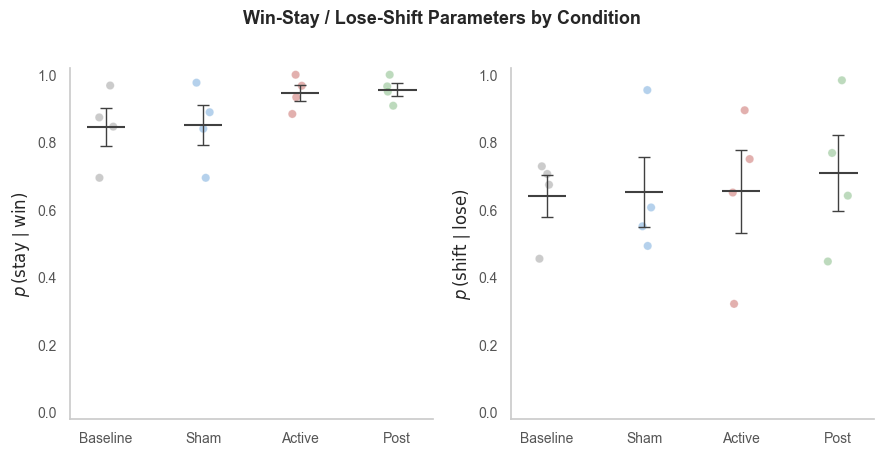

In [14]:
# Visualize WSLS by condition

# --- Plot style ---
# Muted palette with thin outlines; inspired by clean academic figures.
# Individual points shown small + transparent; means as thin gray lines with error bars.

condition_order = ['baseline', 'sham', 'active', 'post']
palette = {
    'baseline': '#8C8C8C',  # warm gray
    'sham':     '#5B9BD5',  # steel blue
    'active':   '#C0504D',  # muted brick red
    'post':     '#6DAF6D',  # sage green
}

fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))

for ax, (param, label) in zip(axes,
    [('p_stay_win', r'$p\,(\mathrm{stay} \mid \mathrm{win})$'),
     ('p_shift_lose', r'$p\,(\mathrm{shift} \mid \mathrm{lose})$')]):

    plot_data = wsls[wsls['condition'].isin(condition_order)].copy()

    # Individual data points — small, transparent, jittered
    sns.stripplot(
        data=plot_data, x='condition', y=param, order=condition_order,
        palette=palette, size=6, alpha=0.45, jitter=0.12,
        edgecolor='white', linewidth=0.4, ax=ax, zorder=2,
    )

    # Mean + SEM error bars — thin gray lines
    for i, cond in enumerate(condition_order):
        vals = plot_data.loc[plot_data['condition'] == cond, param].dropna()
        if len(vals) == 0:
            continue
        mean = vals.mean()
        sem = vals.sem() if len(vals) > 1 else 0

        # Error bar
        ax.errorbar(
            i, mean, yerr=sem,
            fmt='none', color='#404040', capsize=4, capthick=1.0,
            elinewidth=1.0, zorder=3,
        )
        # Mean line (thin horizontal dash)
        ax.hlines(
            mean, i - 0.2, i + 0.2,
            color='#404040', linewidth=1.5, zorder=4,
        )

    # --- Axis styling ---
    ax.set_ylabel(label, fontsize=12)
    ax.set_xlabel('')  # condition labels are self-explanatory
    ax.set_ylim(-0.02, 1.02)
    ax.set_xticklabels([c.capitalize() for c in condition_order], fontsize=10)
    ax.tick_params(axis='y', labelsize=10)

    # Clean frame: remove top/right spines, lighten remaining
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#CCCCCC')
    ax.spines['bottom'].set_color('#CCCCCC')
    ax.tick_params(colors='#555555')
    ax.grid(False)

fig.suptitle('Win-Stay / Lose-Shift Parameters by Condition',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


## 4. Rescorla-Wagner Model Fitting

Fit a simple Rescorla-Wagner model to each subject's data within each condition. The model has two free parameters:
- **α** (learning rate): how quickly values are updated after feedback
- **β** (inverse temperature): how deterministically choices follow learned values

Values are initialized at 0.5 (equal preference). Choice probabilities are computed via softmax.

In [ ]:
def rescorla_wagner_nll(params, choices, rewards):
    """
    Negative log-likelihood for a simple Rescorla-Wagner model.
    
    Parameters
    ----------
    params : array [alpha, beta]
        alpha: learning rate (0, 1)
        beta: inverse temperature (0, inf)
    choices : array of int (1 or 2)
        Participant's choice on each trial
    rewards : array of bool
        Whether each trial was rewarded
    
    Returns
    -------
    float : negative log-likelihood
    """
    alpha, beta = params
    
    # Initialize values for both options
    Q = np.array([0.5, 0.5])
    nll = 0.0
    
    for choice, reward in zip(choices, rewards):
        # Softmax choice probability
        exp_vals = np.exp(beta * (Q - np.max(Q)))  # numerically stable softmax
        p = exp_vals / exp_vals.sum()
        
        # Choice index (0-indexed)
        c = int(choice) - 1
        
        # Accumulate log-likelihood (clipped to avoid log(0))
        nll -= np.log(np.clip(p[c], 1e-8, 1.0))
        
        # Update chosen option's value
        r = float(reward)
        Q[c] += alpha * (r - Q[c])
    
    return nll


def fit_rescorla_wagner(choices, rewards, n_starts=10):
    """
    Fit RW model using multiple random starting points.
    
    Returns
    -------
    dict with keys: alpha, beta, nll, bic, converged
    """
    n_trials = len(choices)
    bounds = [(0.001, 0.999), (0.01, 50.0)]  # alpha, beta
    
    best_result = None
    best_nll = np.inf
    
    for _ in range(n_starts):
        # Random initial parameters
        x0 = [np.random.uniform(0.01, 0.99), np.random.uniform(0.1, 10.0)]
        
        result = optimize.minimize(
            rescorla_wagner_nll, x0, args=(choices, rewards),
            bounds=bounds, method='L-BFGS-B'
        )
        
        if result.fun < best_nll:
            best_nll = result.fun
            best_result = result
    
    # BIC = k*ln(n) - 2*ln(L)
    k = 2  # number of free parameters
    bic = k * np.log(n_trials) + 2 * best_nll
    
    # Check for boundary values (convergence failure flag per pre-reg)
    alpha, beta = best_result.x
    at_boundary = (alpha <= 0.002 or alpha >= 0.998 or beta <= 0.02 or beta >= 49.9)
    
    return {
        'alpha': alpha,
        'beta': beta,
        'nll': best_nll,
        'bic': bic,
        'at_boundary': at_boundary,
        'converged': best_result.success
    }

In [ ]:
# Fit RW model for each subject x condition
rw_results = []

for (sub_id, condition), group in data.groupby(['subject_id', 'condition']):
    # Drop missed trials
    valid = group.dropna(subset=['choice', 'reward'])
    
    if len(valid) < 10:  # need minimum trials for stable estimation
        print(f'  sub-{sub_id} {condition}: only {len(valid)} valid trials, skipping')
        continue
    
    fit = fit_rescorla_wagner(valid['choice'].values, valid['reward'].values)
    fit['subject_id'] = sub_id
    fit['condition'] = condition
    fit['n_trials'] = len(valid)
    rw_results.append(fit)

rw = pd.DataFrame(rw_results)

print('Rescorla-Wagner parameter estimates:')
print(rw[['subject_id', 'condition', 'alpha', 'beta', 'nll', 'bic', 'at_boundary']]
      .to_string(index=False, float_format='{:.3f}'.format))

# Flag boundary cases
if rw['at_boundary'].any():
    print('\n⚠ WARNING: Some fits hit parameter boundaries (potential convergence failure):')
    print(rw[rw['at_boundary']][['subject_id', 'condition', 'alpha', 'beta']])

In [ ]:
# =============================================================================
# Visualize Rescorla-Wagner Parameters by Condition
# =============================================================================
# Drop in directly after the RW fitting kernel.
# Uses the same aesthetic conventions as the WSLS plots:
#   - Muted palette, small transparent individual points
#   - Thin gray mean lines with SEM error bars
#   - Clean frame (no top/right spines, no grid)
#   - LaTeX-rendered parameter labels

condition_order = ['baseline', 'sham', 'active', 'post']
palette = {
    'baseline': '#8C8C8C',  # warm gray
    'sham':     '#5B9BD5',  # steel blue
    'active':   '#C0504D',  # muted brick red
    'post':     '#6DAF6D',  # sage green
}

fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))

for ax, (param, label, ylim) in zip(axes, [
    ('alpha', r'$\alpha$ (Learning Rate)', (0, 1.02)),
    ('beta',  r'$\beta$ (Inverse Temperature)', None),
]):
    plot_data = rw[rw['condition'].isin(condition_order)].copy()

    # --- Individual data points ---
    sns.stripplot(
        data=plot_data, x='condition', y=param, order=condition_order,
        palette=palette, size=6, alpha=0.45, jitter=0.12,
        edgecolor='white', linewidth=0.4, ax=ax, zorder=2,
    )

    # --- Mean + SEM error bars ---
    for i, cond in enumerate(condition_order):
        vals = plot_data.loc[plot_data['condition'] == cond, param].dropna()
        if len(vals) == 0:
            continue
        mean = vals.mean()
        sem = vals.sem() if len(vals) > 1 else 0

        # Error bar
        ax.errorbar(
            i, mean, yerr=sem,
            fmt='none', color='#404040', capsize=4, capthick=1.0,
            elinewidth=1.0, zorder=3,
        )
        # Mean line (thin horizontal dash)
        ax.hlines(
            mean, i - 0.2, i + 0.2,
            color='#404040', linewidth=1.5, zorder=4,
        )

    # --- Flag boundary fits ---
    boundary_pts = plot_data[plot_data['at_boundary']]
    if len(boundary_pts) > 0:
        for i, cond in enumerate(condition_order):
            bnd = boundary_pts[boundary_pts['condition'] == cond]
            if len(bnd) > 0:
                ax.scatter(
                    [i] * len(bnd), bnd[param],
                    marker='x', color='#CC0000', s=50, linewidths=1.2,
                    zorder=5, label='Boundary fit' if i == 0 else '',
                )

    # --- Axis styling ---
    ax.set_ylabel(label, fontsize=12)
    ax.set_xlabel('')
    if ylim is not None:
        ax.set_ylim(ylim)
    ax.set_xticklabels([c.capitalize() for c in condition_order], fontsize=10)
    ax.tick_params(axis='y', labelsize=10)

    # Clean frame
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#CCCCCC')
    ax.spines['bottom'].set_color('#CCCCCC')
    ax.tick_params(colors='#555555')
    ax.grid(False)

fig.suptitle('Rescorla-Wagner Parameters by Condition',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 5. Merge with REDCap Data

Pull in cognitive scores, demographics, and BIS/BAS from the R01 REDCap export. Cognitive composites are computed from raw (non-age-normed) scores, z-transformed within sample.

**Note:** The current REDCap export contains HVLT and Salthouse measures. Additional measures (Digit Span, n-back, flanker, BVMT, TMT-A, BIS/BAS) will need to be added from a supplemental export when available.

In [ ]:
# Load REDCap data
redcap = pd.read_csv(REDCAP_PATH)
redcap.rename(columns={'Subject ID': 'subject_id'}, inplace=True)
redcap['subject_id'] = redcap['subject_id'].astype(str)

# Select relevant columns (expand as more measures become available)
redcap_cols = {
    'subject_id': 'subject_id',
    'Age': 'age',
    'Gender': 'gender',
    'Race': 'race',
    'Ethnicity': 'ethnicity',
    'HVLT Total Immediate Recall': 'hvlt_immediate',
    'HVLT Delay Score': 'hvlt_delay',
    'Salthouse Letter Comparison': 'salthouse_letter',
    'Salthouse Pattern Comparison': 'salthouse_pattern',
    'KBIT IQ (age adjusted)': 'kbit_iq',
    'scd_score_total': 'scd_total',
}

# Only keep columns that exist in the export
available_cols = {k: v for k, v in redcap_cols.items() if k in redcap.columns}
demographics = redcap[list(available_cols.keys())].rename(columns=available_cols).copy()

# Filter to our study subjects
study_subs = list(SUBJECT_INFO.keys())
demographics = demographics[demographics['subject_id'].isin(study_subs)]

print(f'REDCap data loaded for {len(demographics)} subjects')
print(demographics.to_string(index=False))

In [ ]:
def compute_cognitive_composites(df):
    """
    Compute z-scored cognitive domain composites from raw scores.
    
    Domains (per pre-registration):
        Attention/Working Memory: Digit Span, n-back, flanker
        Episodic Memory: HVLT, BVMT
        Processing Speed: Salthouse Letter, Salthouse Pattern, TMT-A
    
    Currently available: HVLT, Salthouse Letter/Pattern.
    Composites are computed from whatever measures are present;
    missing domains are left as NaN.
    """
    df = df.copy()
    
    # --- Z-transform available raw scores within sample ---
    score_cols = ['hvlt_immediate', 'hvlt_delay', 'salthouse_letter', 'salthouse_pattern']
    for col in score_cols:
        if col in df.columns:
            df[f'{col}_z'] = stats.zscore(pd.to_numeric(df[col], errors='coerce'), nan_policy='omit')
    
    # --- Domain composites ---
    # Attention/Working Memory: placeholder until Digit Span, n-back, flanker available
    attn_cols = []  # TODO: add 'digit_span_z', 'nback_z', 'flanker_z'
    if attn_cols:
        df['composite_attention_wm'] = df[attn_cols].mean(axis=1)
    else:
        df['composite_attention_wm'] = np.nan
    
    # Episodic Memory: HVLT available, BVMT pending
    mem_cols = [c for c in ['hvlt_immediate_z', 'hvlt_delay_z'] if c in df.columns]
    if mem_cols:
        df['composite_episodic_memory'] = df[mem_cols].mean(axis=1)
    else:
        df['composite_episodic_memory'] = np.nan
    
    # Processing Speed: Salthouse available, TMT-A pending
    speed_cols = [c for c in ['salthouse_letter_z', 'salthouse_pattern_z'] if c in df.columns]
    if speed_cols:
        df['composite_processing_speed'] = df[speed_cols].mean(axis=1)
    else:
        df['composite_processing_speed'] = np.nan
    
    # Global composite: average across available domains
    domain_cols = ['composite_attention_wm', 'composite_episodic_memory', 'composite_processing_speed']
    available_domains = [c for c in domain_cols if df[c].notna().any()]
    if available_domains:
        df['composite_global'] = df[available_domains].mean(axis=1)
    else:
        df['composite_global'] = np.nan
    
    return df


demographics = compute_cognitive_composites(demographics)

composite_cols = [c for c in demographics.columns if c.startswith('composite_')]
print('Cognitive composites:')
print(demographics[['subject_id', 'age'] + composite_cols].to_string(index=False, float_format='{:.3f}'.format))

## 6. Assemble Analysis Dataframes

Create the subject-level datasets needed for each hypothesis test:
- **H1 dataset**: Sham-condition WSLS/RW parameters + cognitive composites + demographics  
- **H2 dataset**: Within-subject change scores (active − sham) + demographics

In [ ]:
# --- H1 dataset: baseline (sham) parameters + individual differences ---
wsls_sham = wsls[wsls['condition'] == 'sham'].copy()
rw_sham = rw[rw['condition'] == 'sham'][['subject_id', 'alpha', 'beta', 'at_boundary']].copy()
rw_sham.rename(columns={'alpha': 'rw_alpha', 'beta': 'rw_beta', 'at_boundary': 'rw_at_boundary'}, inplace=True)

h1_data = wsls_sham.merge(rw_sham, on='subject_id', how='left')
h1_data = h1_data.merge(demographics, on='subject_id', how='left')

print('H1 analysis dataset:')
print(h1_data[['subject_id', 'p_stay_win', 'p_shift_lose', 'rw_alpha', 'rw_beta', 'age']]
      .to_string(index=False, float_format='{:.3f}'.format))

# --- H2 dataset: within-subject change scores ---
wsls_active = wsls[wsls['condition'] == 'active'].set_index('subject_id')
wsls_sham_idx = wsls[wsls['condition'] == 'sham'].set_index('subject_id')

# Change scores: active minus sham
h2_data = pd.DataFrame({
    'subject_id': wsls_active.index,
    'delta_p_stay_win': wsls_active['p_stay_win'].values - wsls_sham_idx.loc[wsls_active.index, 'p_stay_win'].values,
    'delta_p_shift_lose': wsls_active['p_shift_lose'].values - wsls_sham_idx.loc[wsls_active.index, 'p_shift_lose'].values,
    'active_p_stay_win': wsls_active['p_stay_win'].values,
    'sham_p_stay_win': wsls_sham_idx.loc[wsls_active.index, 'p_stay_win'].values,
    'active_p_shift_lose': wsls_active['p_shift_lose'].values,
    'sham_p_shift_lose': wsls_sham_idx.loc[wsls_active.index, 'p_shift_lose'].values,
}).reset_index(drop=True)

h2_data = h2_data.merge(demographics, on='subject_id', how='left')

print('\nH2 analysis dataset (change scores):')
print(h2_data[['subject_id', 'delta_p_stay_win', 'delta_p_shift_lose', 'age']]
      .to_string(index=False, float_format='{:.3f}'.format))

## 7. H1 Analyses: Cognitive Function and Reward Sensitivity Predict Baseline Learning

**H1.1:** Poorer cognitive function → elevated p(stay|win), reduced p(shift|lose)  
**H1.2:** Lower reward sensitivity (BAS, β) → same pattern, independent of cognitive function

**Method:** Linear regression with simultaneous entry of age, education (covariates), cognitive function (global composite), and reward sensitivity (BAS). Separate models for each DV. ΔR² computed by comparing full model to reduced (age + education only).

⚠ *With N=2, these models cannot be estimated. This section will run once sufficient data is collected.*

In [ ]:
import statsmodels.api as sm
from statsmodels.stats.anova import anova_lm


def run_h1_regression(df, dv, covariates, predictors):
    """
    Run H1 regression with model comparison for ΔR².
    
    Parameters
    ----------
    df : DataFrame with all variables
    dv : str, dependent variable column name
    covariates : list of str, covariate column names (Step 1: age, education)
    predictors : list of str, predictor column names (cognitive function, BAS)
    
    Returns
    -------
    dict with reduced model, full model, and ΔR² test results
    """
    # Drop rows with missing data in any relevant column
    all_vars = [dv] + covariates + predictors
    clean = df.dropna(subset=all_vars)
    
    if len(clean) < len(all_vars) + 2:  # need df > 0
        print(f'  Insufficient data for {dv} (N={len(clean)}, need ≥{len(all_vars)+2})')
        return None
    
    y = clean[dv]
    
    # Reduced model (covariates only)
    X_reduced = sm.add_constant(clean[covariates])
    model_reduced = sm.OLS(y, X_reduced).fit()
    
    # Full model (covariates + predictors)
    X_full = sm.add_constant(clean[covariates + predictors])
    model_full = sm.OLS(y, X_full).fit()
    
    # ΔR² = R²_full - R²_reduced
    delta_r2 = model_full.rsquared - model_reduced.rsquared
    
    # F-test for model comparison
    f_test = anova_lm(model_reduced, model_full)
    
    print(f'\n--- {dv} ---')
    print(f'N = {len(clean)}')
    print(f'\nReduced model (covariates only): R² = {model_reduced.rsquared:.3f}')
    print(f'Full model: R² = {model_full.rsquared:.3f}')
    print(f'ΔR² = {delta_r2:.3f}')
    print(f'\nFull model summary:')
    print(model_full.summary2().tables[1].to_string(float_format='{:.3f}'.format))
    
    return {
        'model_reduced': model_reduced,
        'model_full': model_full,
        'delta_r2': delta_r2,
        'f_test': f_test
    }


# --- Run H1 analyses ---
# NOTE: Currently limited by (a) sample size and (b) missing BAS/education data.
# Covariates and predictors will be populated as data becomes available.

MIN_N_REGRESSION = 10  # minimum sample for attempting regression

if len(h1_data) >= MIN_N_REGRESSION:
    covariates = ['age']  # TODO: add 'education' when available
    predictors = ['composite_global']  # TODO: add 'bas_total' when available
    
    h1_stay = run_h1_regression(h1_data, 'p_stay_win', covariates, predictors)
    h1_shift = run_h1_regression(h1_data, 'p_shift_lose', covariates, predictors)
else:
    print(f'H1 analyses deferred: N={len(h1_data)}, need ≥{MIN_N_REGRESSION}')
    print('Will run once sufficient participants have completed the study.')

## 8. H2.1 Analysis: tACS vs. Sham (Paired t-tests)

**H2.1:** Theta-tACS will reduce p(stay|win) and/or increase p(shift|lose) relative to sham.

**Method:** Paired t-tests on each DV. Effect size: Cohen's dz. Non-significant results followed by equivalence tests (TOST, dz = ±0.3).

⚠ *Requires paired data. Will run when N ≥ 5 for initial inspection.*

In [ ]:
def paired_ttest_with_equivalence(active, sham, dv_name, equiv_bound=0.3):
    """
    Paired t-test with Cohen's dz and TOST equivalence test.
    
    Parameters
    ----------
    active, sham : arrays of matched observations
    dv_name : str for labeling output
    equiv_bound : float, equivalence bound in dz units (default ±0.3)
    """
    diff = active - sham
    n = len(diff)
    
    # Paired t-test
    t_stat, p_val = stats.ttest_rel(active, sham)
    
    # Cohen's dz
    dz = diff.mean() / diff.std(ddof=1)
    
    print(f'--- {dv_name} ---')
    print(f'N = {n}')
    print(f'Active: M={active.mean():.3f}, SD={active.std():.3f}')
    print(f'Sham:   M={sham.mean():.3f}, SD={sham.std():.3f}')
    print(f'Diff:   M={diff.mean():.3f}, SD={diff.std():.3f}')
    print(f't({n-1}) = {t_stat:.3f}, p = {p_val:.4f}')
    print(f"Cohen's dz = {dz:.3f}")
    
    # TOST equivalence test if primary test is non-significant
    if p_val > 0.05:
        print(f'\nTOST equivalence test (bounds: dz = ±{equiv_bound}):')
        # Convert dz bound to raw difference units
        bound_raw = equiv_bound * diff.std(ddof=1)
        
        # Upper-bound test: H0: diff >= +bound
        t_upper = (diff.mean() - bound_raw) / (diff.std(ddof=1) / np.sqrt(n))
        p_upper = stats.t.cdf(t_upper, df=n-1)  # one-tailed
        
        # Lower-bound test: H0: diff <= -bound
        t_lower = (diff.mean() + bound_raw) / (diff.std(ddof=1) / np.sqrt(n))
        p_lower = 1 - stats.t.cdf(t_lower, df=n-1)  # one-tailed
        
        p_tost = max(p_upper, p_lower)
        print(f'  p(TOST) = {p_tost:.4f}')
        if p_tost < 0.05:
            print(f'  → Effect is statistically equivalent to zero (within ±{equiv_bound} dz)')
        else:
            print(f'  → Cannot establish equivalence')
    
    return {'t': t_stat, 'p': p_val, 'dz': dz, 'n': n}


# --- Run H2.1 ---
MIN_N_TTEST = 5

if len(h2_data) >= MIN_N_TTEST:
    print('H2.1: tACS vs. Sham paired comparisons\n')
    
    h21_stay = paired_ttest_with_equivalence(
        h2_data['active_p_stay_win'].values, 
        h2_data['sham_p_stay_win'].values,
        'P(stay|win)'
    )
    print()
    h21_shift = paired_ttest_with_equivalence(
        h2_data['active_p_shift_lose'].values,
        h2_data['sham_p_shift_lose'].values,
        'P(shift|lose)'
    )
else:
    print(f'H2.1 analyses deferred: N={len(h2_data)}, need ≥{MIN_N_TTEST}')
    # Still show the raw values for inspection
    if len(h2_data) > 0:
        print('\nPreliminary values (not for inference):')
        print(h2_data[['subject_id', 'sham_p_stay_win', 'active_p_stay_win', 'delta_p_stay_win',
                        'sham_p_shift_lose', 'active_p_shift_lose', 'delta_p_shift_lose']]
              .to_string(index=False, float_format='{:.3f}'.format))

## 9. H2.2 Analysis: Age Moderation of tACS Effects

**H2.2:** Age moderates tACS-induced changes, with older adults showing different effects.

**Method:** Linear regression predicting change scores (active − sham) from age, controlling for cognitive function. Additional model adds DLPFC thickness.

⚠ *Acknowledged as underpowered at N=35; treated as exploratory.*

In [ ]:
def run_h22_regression(df, dv):
    """
    H2.2 regression: age predicting tACS change scores.
    """
    # Primary model: age controlling for cognitive function
    predictors_primary = ['age']  # TODO: add 'composite_global' when N is sufficient
    
    clean = df.dropna(subset=[dv] + predictors_primary)
    
    if len(clean) < len(predictors_primary) + 3:
        print(f'  Insufficient data for {dv} (N={len(clean)})')
        return None
    
    y = clean[dv]
    X = sm.add_constant(clean[predictors_primary])
    model = sm.OLS(y, X).fit()
    
    print(f'\n--- {dv} ---')
    print(f'N = {len(clean)}')
    print(model.summary2().tables[1].to_string(float_format='{:.3f}'.format))
    print(f'R² = {model.rsquared:.3f}')
    
    return model


# --- Run H2.2 ---
if len(h2_data) >= MIN_N_REGRESSION:
    print('H2.2: Age moderation of tACS effects\n')
    h22_stay = run_h22_regression(h2_data, 'delta_p_stay_win')
    h22_shift = run_h22_regression(h2_data, 'delta_p_shift_lose')
else:
    print(f'H2.2 analyses deferred: N={len(h2_data)}, need ≥{MIN_N_REGRESSION}')

## 10. Descriptive Summary and Quality Checks

Overview of sample characteristics, task performance, and data quality metrics.

In [ ]:
# --- Exclusion criteria checks ---
print('=== Data Quality Checks ===\n')

for sub_id in data['subject_id'].unique():
    sub_data = data[data['subject_id'] == sub_id]
    print(f'sub-{sub_id}:')
    
    for run_num in sorted(sub_data['run'].unique()):
        run_data = sub_data[sub_data['run'] == run_num]
        n_total = len(run_data)
        n_missed = run_data['choice'].isna().sum()
        pct_missed = 100 * n_missed / n_total
        
        # Single-side bias check (>95% same choice)
        valid_choices = run_data['choice'].dropna()
        if len(valid_choices) > 0:
            choice_pcts = valid_choices.value_counts(normalize=True)
            max_bias = choice_pcts.max()
        else:
            max_bias = np.nan
        
        condition = run_data['condition'].iloc[0]
        flags = []
        if pct_missed > 20:
            flags.append(f'⚠ {pct_missed:.0f}% missed (EXCLUDE)')
        if max_bias > 0.95:
            flags.append(f'⚠ {max_bias:.0%} same choice (EXCLUDE)')
        
        flag_str = ' '.join(flags) if flags else '✓'
        print(f'  Run {run_num} ({condition:>8s}): {n_total} trials, '
              f'{n_missed} missed ({pct_missed:.1f}%), '
              f'max choice bias={max_bias:.1%} {flag_str}')
    print()

In [ ]:
# --- Learning curves: accuracy over trials within each condition ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, sub_id in zip(axes, data['subject_id'].unique()):
    sub_data = data[(data['subject_id'] == sub_id) & data['correct'].notna()]
    
    for condition in ['baseline', 'sham', 'active', 'post']:
        cond_data = sub_data[sub_data['condition'] == condition]
        if len(cond_data) == 0:
            continue
        
        # Rolling accuracy (window=10 trials)
        acc = cond_data['correct'].astype(float).rolling(10, min_periods=5).mean()
        ax.plot(range(len(acc)), acc, label=condition, color=palette.get(condition, 'gray'), alpha=0.8)
    
    ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='chance')
    ax.axhline(WIN_FRACTION, color='gray', linestyle=':', alpha=0.5, label=f'optimal ({WIN_FRACTION})')
    ax.set_xlabel('Trial (within condition)')
    ax.set_ylabel('Accuracy (rolling 10-trial window)')
    ax.set_title(f'sub-{sub_id}')
    ax.legend(fontsize=8)
    ax.set_ylim(0, 1)

fig.suptitle('Learning Curves by Condition', fontweight='bold')
plt.tight_layout()
plt.show()

## 11. Summary Table

Consolidated parameter table across all subjects and conditions.

In [ ]:
# Merge WSLS and RW into a single summary
summary = wsls.merge(
    rw[['subject_id', 'condition', 'alpha', 'beta', 'bic', 'at_boundary']],
    on=['subject_id', 'condition'],
    how='left'
)

# Add demographics
summary = summary.merge(
    demographics[['subject_id', 'age', 'gender']],
    on='subject_id',
    how='left'
)

display_cols = ['subject_id', 'age', 'condition', 'n_total_trials',
                'p_stay_win', 'p_shift_lose', 'alpha', 'beta', 'bic']
print(summary[display_cols].sort_values(['subject_id', 'condition'])
      .to_string(index=False, float_format='{:.3f}'.format))

---

## TODO / Notes for Future Updates

**Data pending:**
- BIS/BAS scores (needed for H1.2 reward sensitivity predictor)
- Digit Span, n-back, flanker scores (Attention/Working Memory composite)
- BVMT scores (Episodic Memory composite)
- Trail Making A (Processing Speed composite)
- Education (covariate in H1 models)
- DLPFC thickness (H2.2 additional model)
- ECog, SCD-Q (Exploratory analysis 2)

**Analysis extensions:**
- Secondary analyses (Section 8 of pre-reg): baseline rigidity, cognitive function, and reward sensitivity as tACS moderators
- Exploratory RW parameter change scores (active − sham) for α and β
- SimNIBS electric field modeling integration
- Cortical thinning rate predictors
- Domain-specific cognitive composites (Exploratory analysis 3)

**Subject tracker:**
- Migrate SUBJECT_INFO to external CSV/JSON for easier maintenance as N grows